In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import numpy as np
import os
import re

In [2]:
# import dataset as anndata object

dir = "PBMC_datasets/4/lognorm/" # using lognorm data (raw data isnt really raw)

adata = sc.read_10x_mtx(
    dir,
    var_names="gene_symbols",
    cache=False
)
adata.var_names_make_unique()

In [ ]:
print(adata)

AnnData object with n_obs × n_vars = 270884 × 22465
    var: 'gene_ids'


In [4]:
display(adata.obs.head())
display(adata.var.head()) 

""
G1010_y2_AAACCTGAGCTGATAA-1
G1010_y2_AAACCTGCAAGCCCAC-1
G1010_y2_AAACCTGCACGCATCG-1
G1010_y2_AAACCTGCATACTACG-1
G1010_y2_AAACCTGGTAAGGGAA-1


,gene_ids
AL627309.1,AL627309.1
AL627309.5,AL627309.5
LINC01409,LINC01409
FAM87B,FAM87B
LINC01128,LINC01128


In [5]:
pd.DataFrame(
    adata.X[:10, :20].toarray(),
    index=adata.obs_names[:10],
    columns=adata.var_names[:20]
)

,AL627309.1,AL627309.5,LINC01409,FAM87B,LINC01128,LINC00115,NOC2L,KLHL17,PLEKHN1,HES4,ISG15,AGRN,C1orf159,TTLL10,TNFRSF18,TNFRSF4,SDF4,B3GALT6,C1QTNF12,AL162741.1
G1010_y2_AAACCTGAGCTGATAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,1.387999,0.000000,0.0,0.0
G1010_y2_AAACCTGCAAGCCCAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,2.091002,0.0,0.000000,2.714798,0.0,0.0
G1010_y2_AAACCTGCACGCATCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,1.274075,0.000000,0.0,0.0
G1010_y2_AAACCTGCATACTACG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0
G1010_y2_AAACCTGGTAAGGGAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0
G1010_y2_AAACCTGGTAGCCTCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.557456,0.0,0.000000,0.0,1.058468,0.0,0.000000,0.000000,0.0,0.0
G1010_y2_AAACCTGGTCTAGCGC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,1.782606,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0
G1010_y2_AAACCTGGTTCATGGT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.618908,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0
G1010_y2_AAACCTGTCGGCGCAT-1,0.0,0.0,0.0,0.0,0.0,0.0,2.680156,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0
G1010_y2_AAACGGGAGCTCCTTC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0


In [6]:
# get prefix (everything before the barcode sequence)
adata.obs['prefix'] = adata.obs_names.str.rsplit('_', n=1).str[0]

# extract just the number from the prefix (to get sample number)
adata.obs['sample'] = adata.obs['prefix'].str.extract(r'G(\d+)')

print(adata.obs['sample'].unique())

['1010' '1020' '1028' '1034' '1052' '1055' '1092' '1111' '1120' '1147'
 '1160' '1162' '1180' '1200' '1236' '1237' '1241' '1273' '1279' '1282'
 '230' '254' '516' '598' '656' '696' '70' '738' '773' '780' '781' '802'
 '820' '836' '863' '905' '906' '911' '912' '917' '921' '932' '942' '947'
 '953' '965' '968' '970' '978' '989']


In [7]:
# Add missing metadata

sample_meta = pd.DataFrame({
    "sample": ["1028", "1241", "906", "1034", "1055", "1092","1120","1160","254","1052","516","696","1273","738","911","1180","773","863","1279","598","917","932","780","802","1020","942","968","1147","781","1111","656","912","978","1282","953","820","1162","989","1010","965","921","230","836","1236","1237","1200","947","70","970","905"],
    "gsm_id": ["GSM7080013","GSM7080014","GSM7080015","GSM7080016","GSM7080017","GSM7080018", "GSM7080019","GSM7080020","GSM7080021","GSM7080022","GSM7080023","GSM7080024","GSM7080025","GSM7080026","GSM7080027","GSM7080028","GSM7080029","GSM7080030","GSM7080031","GSM7080032","GSM7080033","GSM7080034","GSM7080035","GSM7080036","GSM7080037","GSM7080038","GSM7080039","GSM7080040","GSM7080041","GSM7080042","GSM7080043","GSM7080044","GSM7080045","GSM7080046","GSM7080047","GSM7080048","GSM7080049", "GSM7080050","GSM7080051","GSM7080052","GSM7080053","GSM7080054","GSM7080055","GSM7080056","GSM7080057","GSM7080058", "GSM7080059","GSM7080060", "GSM7080061", "GSM7080062"],
    "diagnosis": ["CTRL", "AD", "AD", "AD", "AD", "AD", "AD", "AD", "AD", "AD", "AD", "AD", "CTRL", "AD", "CTRL", "CTRL", "AD", "AD", "CTRL", "CTRL", "AD", "AD", "CTRL", "AD", "CTRL", "AD", "CTRL", "AD", "CTRL", "CTRL", "AD", "CTRL", "CTRL", "CTRL", "AD", "CTRL", "CTRL", "CTRL", "CTRL", "AD", "AD", "AD", "CTRL", "AD", "AD", "CTRL", "AD", "AD", "CTRL", "CTRL"],
}).set_index("sample")

adata.obs = adata.obs.join(sample_meta, on="sample", how="left")
adata.obs.head()

,prefix,sample,gsm_id,diagnosis
G1010_y2_AAACCTGAGCTGATAA-1,G1010_y2,1010,GSM7080051,CTRL
G1010_y2_AAACCTGCAAGCCCAC-1,G1010_y2,1010,GSM7080051,CTRL
G1010_y2_AAACCTGCACGCATCG-1,G1010_y2,1010,GSM7080051,CTRL
G1010_y2_AAACCTGCATACTACG-1,G1010_y2,1010,GSM7080051,CTRL
G1010_y2_AAACCTGGTAAGGGAA-1,G1010_y2,1010,GSM7080051,CTRL


In [8]:
# Add in age and gender metadata from csv file
meta_df = pd.read_csv("PBMC_datasets/4/SraRunTable.csv")

# subset to desired metadata
meta_df = meta_df[["AGE", "sex", "Library Name"]].rename(columns={"AGE" : "age", "sex" : "gender", "Library Name" : "gsm_id"})

# Drop duplicate gsm_ids before merging
meta_df = meta_df.drop_duplicates(subset="gsm_id")

# merge by gsm_id using pd.concat
adata.obs = adata.obs.reset_index().merge(meta_df, on="gsm_id", how="left").set_index("index")

adata.obs.head()

,prefix,sample,gsm_id,diagnosis,age,gender
index,,,,,,
G1010_y2_AAACCTGAGCTGATAA-1,G1010_y2,1010,GSM7080051,CTRL,74,female
G1010_y2_AAACCTGCAAGCCCAC-1,G1010_y2,1010,GSM7080051,CTRL,74,female
G1010_y2_AAACCTGCACGCATCG-1,G1010_y2,1010,GSM7080051,CTRL,74,female
G1010_y2_AAACCTGCATACTACG-1,G1010_y2,1010,GSM7080051,CTRL,74,female
G1010_y2_AAACCTGGTAAGGGAA-1,G1010_y2,1010,GSM7080051,CTRL,74,female


In [9]:
# calculate proportions of samples in age bands (50-59, 60-69, 70-79, 80+), for age-matching with control dataset

# extract from obs, one row per sample with age and diagnosis
sample_ages = adata.obs[["sample", "age", "diagnosis"]].drop_duplicates(subset="sample").copy()
sample_ages["age"] = pd.to_numeric(sample_ages["age"], errors="coerce")

# define age bands (include a 45-50 bin for this dataset)
bins = [39, 49, 59, 69, 79, 200]
labels = ["40-50", "50-59", "60-69", "70-79", "80+"]

sample_ages["age_band"] = pd.cut(sample_ages["age"], bins=bins, labels=labels, right=True, include_lowest=True)

# overall counts and proportions of samples per age band
age_band_counts = sample_ages["age_band"].value_counts().reindex(labels, fill_value=0)
age_band_props = (age_band_counts / age_band_counts.sum()).round(3)
age_band_counts = pd.DataFrame({"count": age_band_counts, "proportion": age_band_props})

display(age_band_counts)

# proportions by diagnosis (only interested in AD)
by_diag_counts = sample_ages.groupby(["diagnosis", "age_band"]).size().unstack(fill_value=0).reindex(columns=labels, fill_value=0)
by_diag_prop = by_diag_counts.div(by_diag_counts.sum(axis=1), axis=0).round(3)

display(by_diag_counts)
display(by_diag_prop)

# save proprtions per age band by diagnosis
out_path = "/rds/general/user/ztb25/home/PBMC_datasets/4/age_band_props_by_diagnosis.csv"
by_diag_counts.to_csv(out_path)

,count,proportion
40-50,1,0.02
50-59,3,0.06
60-69,15,0.30
70-79,18,0.36
80+,13,0.26


age_band,40-50,50-59,60-69,70-79,80+
diagnosis,,,,,
AD,1,2,8,9,8
CTRL,0,1,7,9,5


age_band,40-50,50-59,60-69,70-79,80+
diagnosis,,,,,
AD,0.036,0.071,0.286,0.321,0.286
CTRL,0.000,0.045,0.318,0.409,0.227


In [18]:
# calculate gender counts, overall and by diagnosis

gender_counts = adata.obs.drop_duplicates("sample")["gender"].value_counts()
gender_by_diag_counts = adata.obs.drop_duplicates("sample").groupby("diagnosis")["gender"].value_counts().unstack(fill_value=0)

display(gender_counts)
display(gender_by_diag_counts)

# samples, not cells


male      26
female    24
Name: gender, dtype: int64

gender,female,male
diagnosis,,
AD,14,14
CTRL,10,12


In [10]:
# Run QC globally

# Annotate mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")  

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"], 
    percent_top=[20],
    log1p=True,
    inplace=True
)

adata # to check new metadata cols

AnnData object with n_obs × n_vars = 270884 × 22465
    obs: 'prefix', 'sample', 'gsm_id', 'diagnosis', 'age', 'gender', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

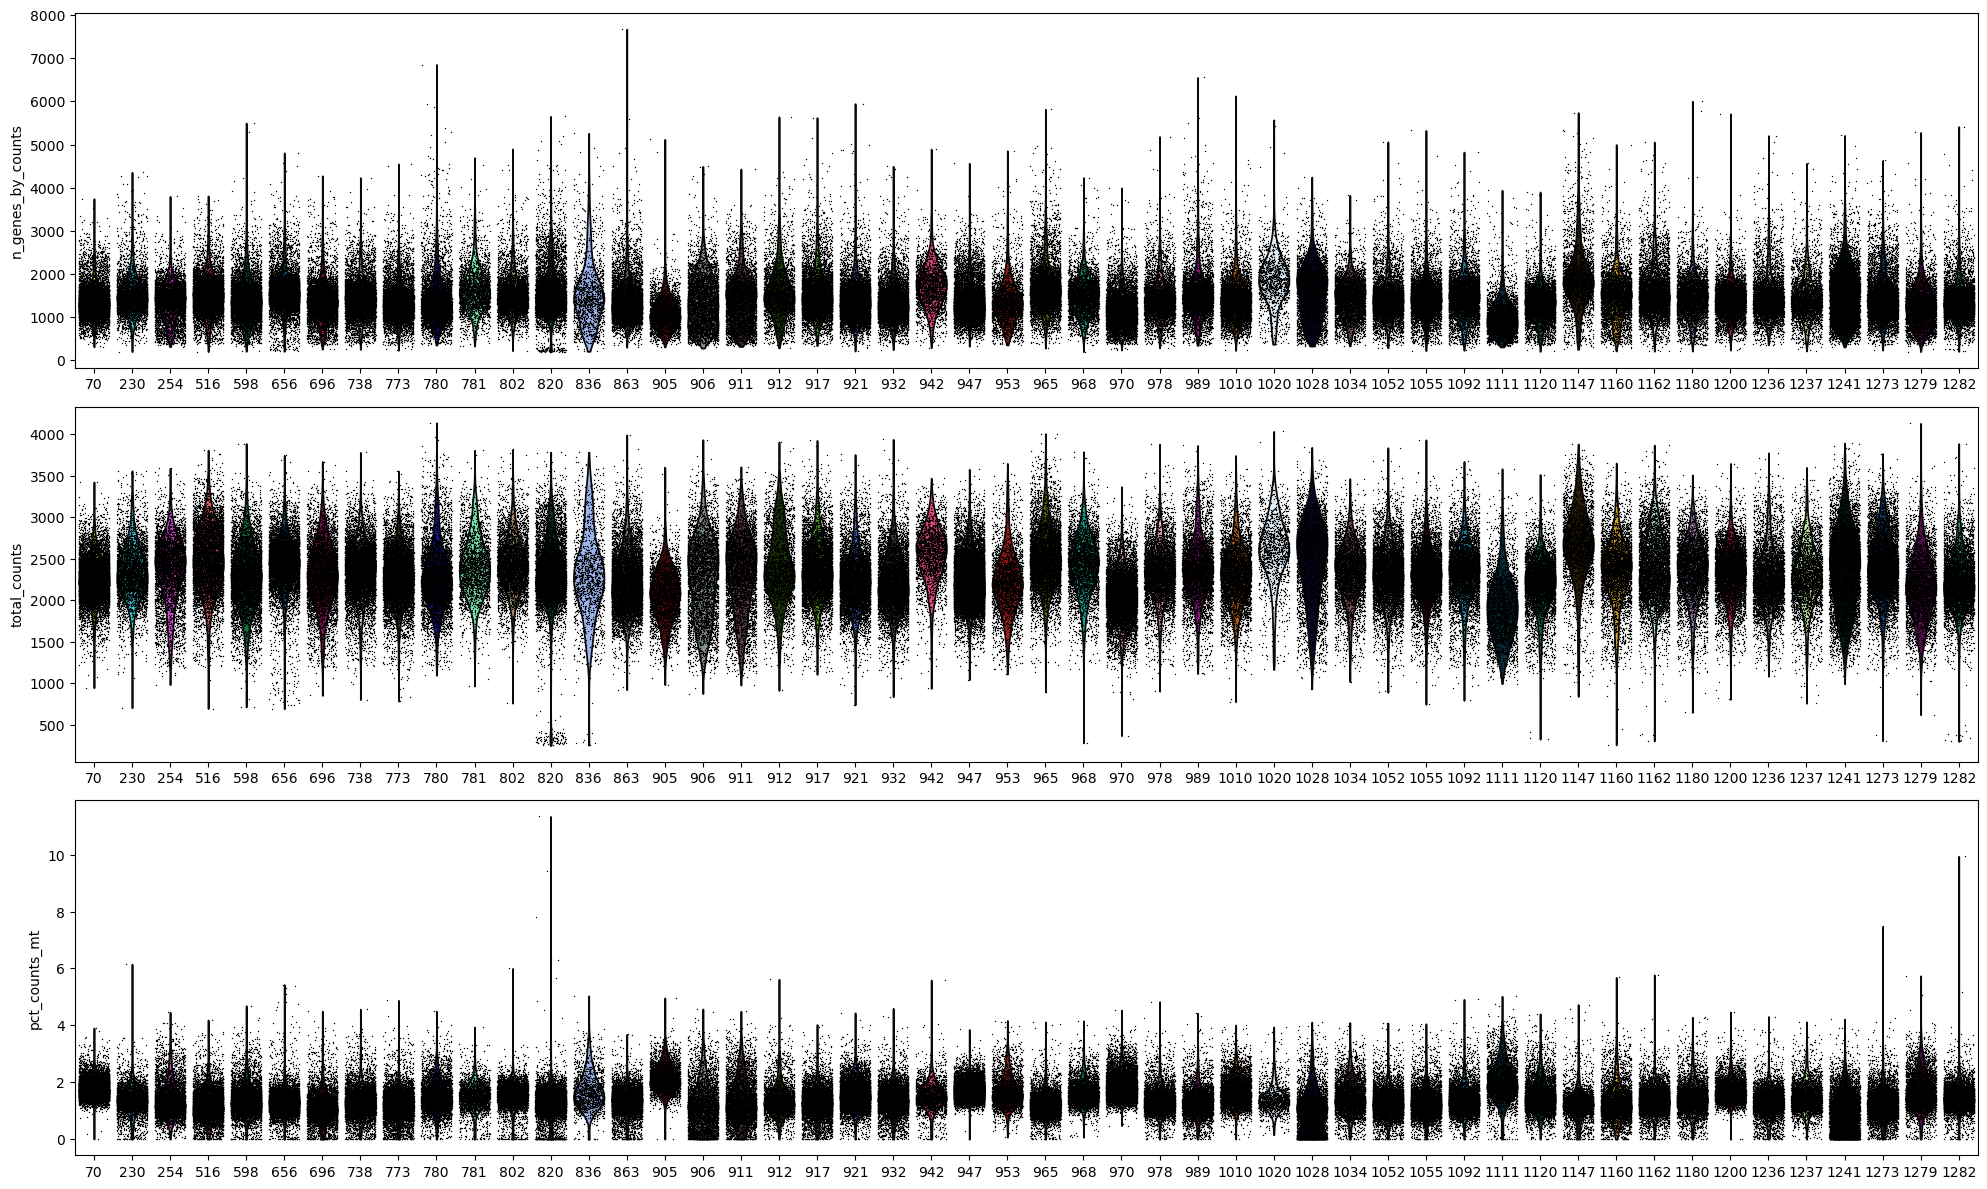

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(20, 12))

for ax, metric in zip(axes, ["n_genes_by_counts", "total_counts", "pct_counts_mt"]):
    sc.pl.violin(adata, metric, groupby="sample", jitter=0.4, ax=ax, show=False)
    ax.set_xlabel("")  

plt.tight_layout()
plt.show()

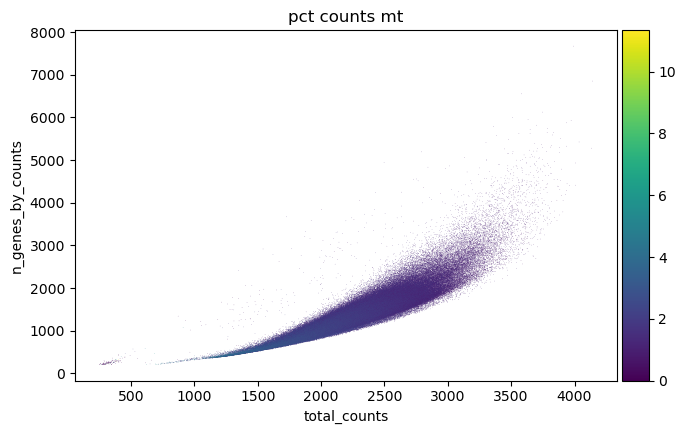

In [12]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [13]:
# Filter out genes not detected in at least 20 cells (not informative)

print(f"Total number of genes: {adata.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=20)
print(f"Number of genes after cell filter: {adata.n_vars}")

Total number of genes: 22465
Number of genes after cell filter: 19528


In [14]:
# Save dataset at this stage (after QC but before log transformation, HVG selection))

# ad.settings.allow_write_nullable_strings = True
# adata.write("/rds/general/user/ztb25/home/PBMC_datasets/4/QC_rawcounts.h5ad")

In [14]:
# Create summary table of number of samples/cells per sample (this case after filtering, as we dont have the before numbers)

cells_per_sample = adata.obs.groupby("sample").size().rename("cells_after_qc")

summary_table = cells_per_sample.reset_index()


# add diagnosis
diag_map = adata.obs[["sample", "diagnosis"]].drop_duplicates()
summary_table = summary_table.merge(diag_map, on="sample", how="left")

total_row = pd.DataFrame([{
    "sample": "TOTAL",
    "cells_after_qc": summary_table["cells_after_qc"].sum(),
    "diagnosis": ""
}])

summary_table = pd.concat([summary_table, total_row], axis=0, ignore_index=True)

# reorder columns
summary_table = summary_table[["sample", "diagnosis", "cells_after_qc"]]

summary_table.to_csv("/rds/general/user/ztb25/home/PBMC_datasets/4/QC_summary_table.csv", index=False)

In [15]:
summary_table

,sample,diagnosis,cells_after_qc
0,70,AD,9721
1,230,AD,4240
2,254,AD,4909
3,516,AD,6589
4,598,CTRL,6213
5,656,AD,7475
6,696,AD,5510
7,738,AD,8334
8,773,AD,9099
9,780,CTRL,5111


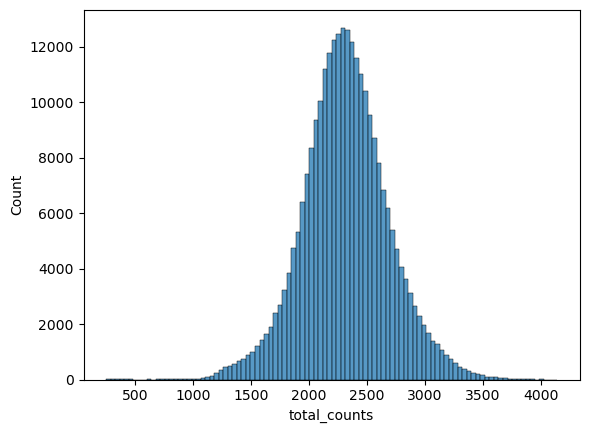

In [16]:
# inspect distribution of the raw counts
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

In [17]:
# Check if log transformed (raw counts can be large, log values are small)
print(adata.X.max())

9.074392


In [18]:
# check on normalisation

# check total counts per cell 
print(adata.obs['total_counts'].describe())


count    270884.000000
mean       2316.770996
std         373.468964
min         251.901215
25%        2086.431274
50%        2309.741577
75%        2543.743713
max        4140.066895
Name: total_counts, dtype: float64


In [20]:
# # renormalise to standard target (median, which is the defauly target_sum)
# scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False) #changes not made to adata.X

# # log transform 
# adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True) 

In [21]:
# # check total counts per cell again
# X_norm = scales_counts["X"]

# norm_totals = np.array(X_norm.sum(axis=1)).flatten()
# print(pd.Series(norm_totals).describe())

In [22]:
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
# axes[0].set_title("Total counts")
# p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
# axes[1].set_title("Shifted logarithm")
# plt.show()

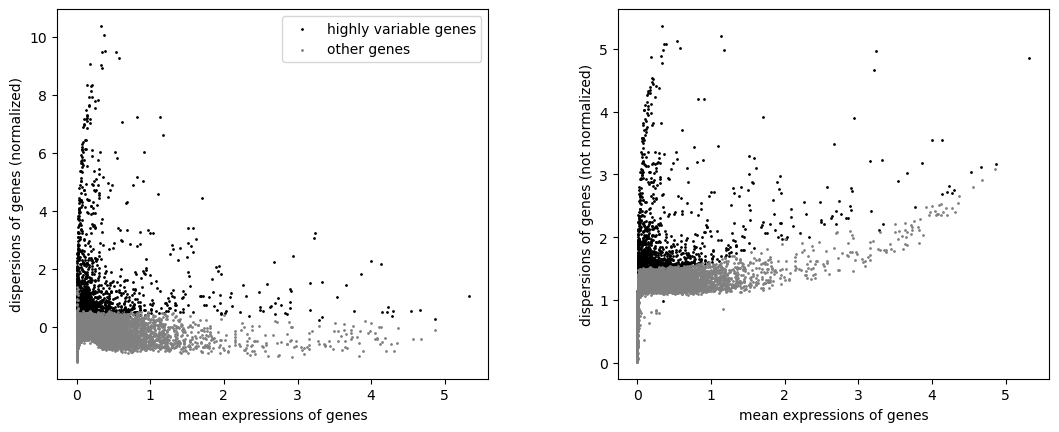

In [19]:
##### Feature Selection ##### ----------------------------------------------------------------------------------------------------
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample") # automatically adds columns to adata.var 'highly_variable', 'means', 'dispersions', 'dispersions_norm'. Downstream functions like pca will automatically use only the HVGs if use_highly_variable=True is passed.
sc.pl.highly_variable_genes(adata)

# Mean expression is simply the average expression level of a gene across all cells — how highly expressed it is on average.
# Dispersion is a measure of how much a gene's expression varies across cells, normalized for its mean.

In [20]:
# Save final dataset for integration

adata.write("/rds/general/user/ztb25/home/PBMC_datasets/4/PBMC4_preprocessed.h5ad")